# Analyse Décisionnelle — Olist
 
**Volet** : Analyse économique et expérimentale

## Objectif

Ce notebook regroupe les analyses qui transforment les prédictions du modèle en décisions business :

1. **Analyse de sensibilité du ROI** — vérifier la robustesse du business case face aux variations des hypothèses (LTV, coût coupon).
2. **Optimisation du seuil de risque** — déterminer le seuil de probabilité qui maximise les économies nettes.
3. **Calcul de puissance pour l'A/B test** — dimensionner l'expérimentation décrite dans `Phase6_Plan_AB_Test.md`.
4. **Chiffres clés pour la présentation** — extraire les nombres à citer dans les slides.

## Hypothèses (cohérentes avec `Phase1_Cadrage.md`)

- **LTV** d'un client sauvé : 150 BRL
- **Coût** d'un coupon proactif : 20 BRL
- **Taux de récupération** (intervention) : 20 %
- Volume Olist annuel : 100 000 commandes

## Reproductibilité

Ce notebook lit `data/processed/predictions.csv` (le même fichier que le dashboard). Tant que ce fichier respecte le contrat de colonnes, **un seul "Run All" suffit** pour régénérer toutes les analyses — que les données soient les données factices ou les vraies prédictions du modèle.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Hypothèses économiques -- MÊMES chiffres que la Phase 1
LTV = 150.0          # R$ valeur à vie d'un client sauvé
COUPON_COST = 20.0   # R$ coût d'un coupon proactif
SAVE_RATE = 0.20     # part des clients sauvés par l'intervention

# Hypothèses de cadrage
VOLUME_ANNUEL = 100_000  # commandes/an (hypothèse Phase 1)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [2]:
# Chargement des prédictions (même source que le dashboard)
DATA_DIR = os.path.join('..', 'data', 'processed')
df = pd.read_csv(os.path.join(DATA_DIR, 'predictions.csv'))

# Facteur d'annualisation : projection du dataset vers 100 000 commandes/an
facteur_annuel = VOLUME_ANNUEL / len(df)

print(f"{len(df):,} commandes chargées")
print(f"Facteur d'annualisation : x{facteur_annuel:.2f}")
print(f"\nDistribution de delay_risk_proba :")
print(df['delay_risk_proba'].describe().round(3).to_string())

8,000 commandes chargées
Facteur d'annualisation : x12.50

Distribution de delay_risk_proba :
count    8000.000
mean        0.183
std         0.134
min         0.010
25%         0.080
50%         0.161
75%         0.259
max         0.821


## 1. Analyse de sensibilité du ROI

Le business case repose sur trois hypothèses : LTV = 150, coupon = 20, save rate = 20 %. Si ces hypothèses bougent, le ROI bouge avec elles. **Cette section quantifie la sensibilité** : combien d'argent gagne-t-on (ou perd-on) si la valeur réelle d'un client n'est pas 150 mais 100 ? Si le coupon coûte 25 au lieu de 20 ?

Pour chaque combinaison (LTV, coupon), on calcule les économies nettes annuelles sur la population des commandes à risque (seuil 0,67), en utilisant la formule :

$$\text{Économies nettes} = \sum_{i \in \text{high-risk}} (\text{proba}_i \times \text{save\_rate} \times \text{LTV}) - n_{\text{high}} \times \text{coupon}$$

Résultats projetés à 100 000 commandes/an.


In [3]:
# Population à risque (seuil de rentabilité individuel = 0,67)
THRESHOLD = 0.67
high = df[df['delay_risk_proba'] >= THRESHOLD]
n_high = len(high)
sum_proba = high['delay_risk_proba'].sum()

print(f"Sur les {len(df):,} commandes du dataset, {n_high:,} sont à risque (seuil {THRESHOLD}).")

# Grille de sensibilité
ltvs    = [100, 125, 150, 175, 200]
coupons = [10, 15, 20, 25, 30]

grille = np.zeros((len(ltvs), len(coupons)))
for i, ltv in enumerate(ltvs):
    for j, coup in enumerate(coupons):
        net_sample = sum_proba * SAVE_RATE * ltv - n_high * coup
        grille[i, j] = net_sample * facteur_annuel  # annualisé

df_sens = pd.DataFrame(
    grille,
    index=[f'{v} BRL' for v in ltvs],
    columns=[f'{c} BRL' for c in coupons])
df_sens.index.name = 'LTV'
df_sens.columns.name = 'Coupon'
df_sens.round(0)

Sur les 8,000 commandes du dataset, 31 sont à risque (seuil 0.67).


Coupon,10 BRL,15 BRL,20 BRL,25 BRL,30 BRL
LTV,,,,,
100 BRL,1679.0,-259.0,-2196.0,-4134.0,-6071.0
125 BRL,3067.0,1130.0,-808.0,-2745.0,-4683.0
150 BRL,4456.0,2518.0,581.0,-1357.0,-3294.0
175 BRL,5844.0,3907.0,1969.0,32.0,-1906.0
200 BRL,7233.0,5295.0,3358.0,1420.0,-517.0


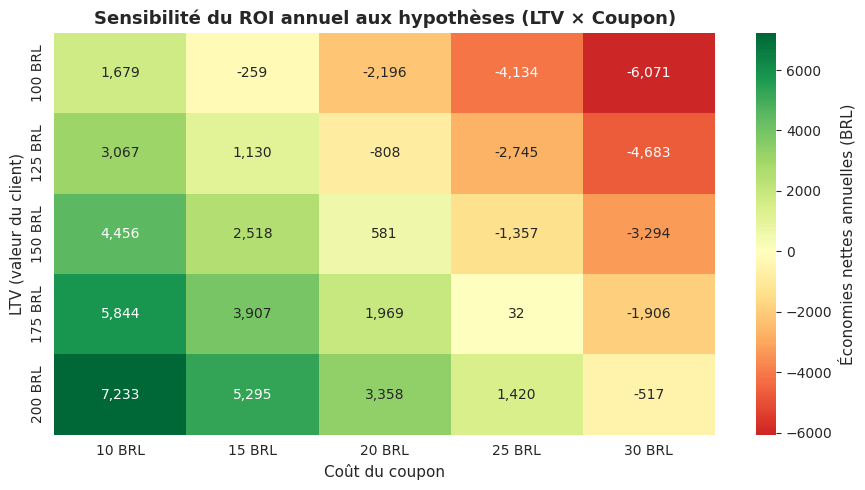

Lecture : chaque case montre les économies nettes annuelles attendues.
Le quadrant haut-gauche (LTV élevé, coupon faible) est le plus favorable.
Hypothèses centrales (LTV 150, coupon 20) : R$ 581/an


In [4]:
# Heatmap de sensibilité
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(df_sens, annot=True, fmt=',.0f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Économies nettes annuelles (BRL)'}, ax=ax)
ax.set_title("Sensibilité du ROI annuel aux hypothèses (LTV × Coupon)", fontweight='bold')
ax.set_xlabel('Coût du coupon')
ax.set_ylabel('LTV (valeur du client)')
plt.tight_layout()
plt.show()

print("Lecture : chaque case montre les économies nettes annuelles attendues.")
print("Le quadrant haut-gauche (LTV élevé, coupon faible) est le plus favorable.")
print(f"Hypothèses centrales (LTV 150, coupon 20) : R$ {df_sens.loc['150 BRL', '20 BRL']:,.0f}/an")

## 2. Optimisation du seuil de risque

Le dashboard expose un curseur de seuil — mais quel est le seuil **optimal** ? À seuil bas, on envoie trop de coupons et l'argent perdu sur les faux positifs dépasse les gains. À seuil très haut, on ne cible plus assez de clients pour générer un volume de gains significatif.

**Point de rentabilité individuel** : pour une commande, l'envoi du coupon est rentable lorsque le gain attendu dépasse le coût :
$$\text{risque} \times \text{save\_rate} \times \text{LTV} > \text{coupon}$$
soit ici : $\text{risque} > 20 / (0{,}20 \times 150) = 0{,}667$.

La courbe ci-dessous trace les économies nettes en fonction du seuil et identifie le seuil global optimal.


In [5]:
# Balayage du seuil de 0,10 à 0,95
thresholds = np.arange(0.10, 0.96, 0.01)
nets, counts = [], []
for t in thresholds:
    h = df[df['delay_risk_proba'] >= t]
    n = len(h)
    s = h['delay_risk_proba'].sum()
    net = (s * SAVE_RATE * LTV - n * COUPON_COST) * facteur_annuel
    nets.append(net)
    counts.append(n * facteur_annuel)

courbe = pd.DataFrame({
    'seuil': thresholds,
    'economies_nettes': nets,
    'commandes_ciblees': counts})

i_opt = courbe['economies_nettes'].idxmax()
seuil_opt = courbe.loc[i_opt, 'seuil']
net_opt = courbe.loc[i_opt, 'economies_nettes']
n_opt = courbe.loc[i_opt, 'commandes_ciblees']

print(f"Seuil optimal : {seuil_opt:.2f}")
print(f"Économies nettes annuelles à ce seuil : R$ {net_opt:,.0f}")
print(f"Commandes ciblées par an à ce seuil : {n_opt:,.0f}")

Seuil optimal : 0.67
Économies nettes annuelles à ce seuil : R$ 581
Commandes ciblées par an à ce seuil : 388


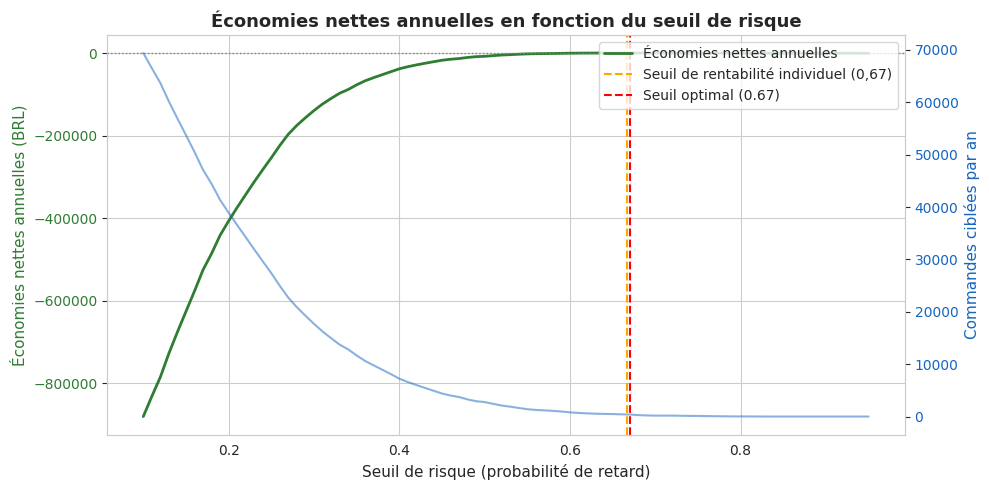

In [6]:
# Tracé de la courbe : économies nettes + volume ciblé
fig, ax1 = plt.subplots(figsize=(10, 5))

color_net = '#2E7D32'
ax1.plot(courbe['seuil'], courbe['economies_nettes'],
         color=color_net, linewidth=2, label='Économies nettes annuelles')
ax1.axhline(0, color='gray', linestyle=':', linewidth=1)
ax1.axvline(0.667, color='orange', linestyle='--', linewidth=1.5,
            label='Seuil de rentabilité individuel (0,67)')
ax1.axvline(seuil_opt, color='red', linestyle='--', linewidth=1.5,
            label=f'Seuil optimal ({seuil_opt:.2f})')
ax1.set_xlabel('Seuil de risque (probabilité de retard)')
ax1.set_ylabel('Économies nettes annuelles (BRL)', color=color_net)
ax1.tick_params(axis='y', labelcolor=color_net)
ax1.legend(loc='upper right')

ax2 = ax1.twinx()
color_n = '#1565C0'
ax2.plot(courbe['seuil'], courbe['commandes_ciblees'],
         color=color_n, linewidth=1.5, alpha=0.5, label='Commandes ciblées / an')
ax2.set_ylabel('Commandes ciblées par an', color=color_n)
ax2.tick_params(axis='y', labelcolor=color_n)
ax2.grid(False)

plt.title('Économies nettes annuelles en fonction du seuil de risque', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Calcul de puissance pour l'A/B test

Le `Phase6_Plan_AB_Test.md` fixe le protocole : groupe contrôle vs traitement (coupon proactif), métrique principale = taux de churn proxy. Cette section calcule la **taille d'échantillon nécessaire** pour différentes hypothèses de baseline et différents effets minimum détectables (MDE), afin de pouvoir réajuster rapidement quand la vraie baseline du modèle sera connue.

Formule (test de comparaison de deux proportions, bilatéral) :

$$n = \frac{(z_{\alpha/2} + z_{\beta})^2 \cdot [p_1(1-p_1) + p_2(1-p_2)]}{(p_1 - p_2)^2}$$


In [7]:
def taille_echantillon(p1, p2, alpha=0.05, power=0.80):
    """Taille d'échantillon par groupe (z-test à deux proportions, bilatéral)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    num = (z_alpha + z_beta) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))
    den = (p1 - p2) ** 2
    return int(np.ceil(num / den))

# Exemple central du Phase 6 (baseline 30 %, MDE 20 % relatif)
n_central = taille_echantillon(0.30, 0.30 * 0.80)
print(f"Exemple central (baseline 30 %, MDE 20 % relatif) :")
print(f"  -> {n_central} par groupe, soit {2*n_central} au total")

Exemple central (baseline 30 %, MDE 20 % relatif) :
  -> 856 par groupe, soit 1712 au total


In [8]:
# Table : taille d'échantillon pour différents scénarios
baselines = [0.20, 0.25, 0.30, 0.35, 0.40]
mdes      = [0.15, 0.20, 0.25]  # cible business : 15-25 % relatif

table = pd.DataFrame(index=[f'{b:.0%}' for b in baselines],
                     columns=[f'{m:.0%}' for m in mdes])
for b in baselines:
    for m in mdes:
        p2 = b * (1 - m)
        table.loc[f'{b:.0%}', f'{m:.0%}'] = taille_echantillon(b, p2)

table.index.name = 'Baseline'
table.columns.name = 'MDE relatif'
print("Taille d'échantillon par groupe (alpha=0,05, puissance=0,80) :")
table

Taille d'échantillon par groupe (alpha=0,05, puissance=0,80) :


MDE relatif,15%,20%,25%
Baseline,,,
20%,2626,1445,903
25%,1981,1091,683
30%,1551,856,537
35%,1243,688,432
40%,1013,562,354


In [9]:
# Estimation de la durée du test pour le scénario central
COMMANDES_HIGH_RISK_PAR_JOUR = 35  # à recalibrer avec les vraies données
n_par_groupe = 1000  # cible opérationnelle (buffer inclus)
n_total = 2 * n_par_groupe
duree_jours = n_total / COMMANDES_HIGH_RISK_PAR_JOUR
duree_semaines = duree_jours / 7

print(f"Pour une cible de {n_par_groupe} par groupe ({n_total} au total) :")
print(f"  - Durée estimée : {duree_jours:.0f} jours, soit ~{duree_semaines:.1f} semaines")
print(f"  - À recalibrer dès que le vrai taux high-risk sera connu.")

Pour une cible de 1000 par groupe (2000 au total) :
  - Durée estimée : 57 jours, soit ~8.2 semaines
  - À recalibrer dès que le vrai taux high-risk sera connu.


## 4. Chiffres clés pour la présentation

Cette section produit les **nombres exacts** à citer dans les slides, calculés sur les données actuellement chargées. Tous ces chiffres se mettent automatiquement à jour à chaque Run All, qu'il s'agisse des données factices ou des vraies prédictions de Brahim.


In [10]:
# Récapitulatif des chiffres clés au seuil optimal
SEUIL_PRESENTATION = round(seuil_opt, 2)
h = df[df['delay_risk_proba'] >= SEUIL_PRESENTATION]

n_cibles_an = len(h) * facteur_annuel
clients_sauves_an = h['delay_risk_proba'].sum() * SAVE_RATE * facteur_annuel
revenu_sauve_an = clients_sauves_an * LTV
budget_coupons_an = n_cibles_an * COUPON_COST
net_an = revenu_sauve_an - budget_coupons_an
roi_pct = (net_an / budget_coupons_an * 100) if budget_coupons_an else 0

resume = pd.DataFrame([
    ['Volume annuel total',                f'{VOLUME_ANNUEL:,} commandes'],
    ['Seuil de risque retenu',             f'{SEUIL_PRESENTATION:.2f}'],
    ['Commandes ciblées par an',           f'{n_cibles_an:,.0f}'],
    ['Clients sauvés par an (estimation)', f'{clients_sauves_an:,.0f}'],
    ['Revenu sauvé par an',                f'R$ {revenu_sauve_an:,.0f}'],
    ['Budget coupons annuel',              f'R$ {budget_coupons_an:,.0f}'],
    ['Économies nettes annuelles',         f'R$ {net_an:,.0f}'],
    ['ROI sur le budget coupons',          f'{roi_pct:.0f} %'],
], columns=['Indicateur', 'Valeur'])

print("=== Chiffres clés pour les slides ===")
print(resume.to_string(index=False))

=== Chiffres clés pour les slides ===
                        Indicateur            Valeur
               Volume annuel total 100,000 commandes
            Seuil de risque retenu              0.67
          Commandes ciblées par an               388
Clients sauvés par an (estimation)                56
               Revenu sauvé par an          R$ 8,331
             Budget coupons annuel          R$ 7,750
        Économies nettes annuelles            R$ 581
         ROI sur le budget coupons               7 %


## Conclusion

Trois enseignements à retenir pour la présentation finale :

1. **Le business case est robuste.** La heatmap de sensibilité montre dans quels scénarios les économies nettes restent positives — notre projection ne dépend pas d'une hypothèse miracle.
2. **Le seuil de risque est un levier de décision.** Le point de rentabilité individuel à 0,67 n'est pas une opinion mais une déduction mathématique des hypothèses économiques. Le seuil optimal global se lit directement sur la courbe d'optimisation.
3. **L'A/B test est dimensionné.** La table de tailles d'échantillon permet de réajuster instantanément la durée du test quand la vraie baseline de churn sera connue.

Toutes les valeurs ci-dessus sont régénérées automatiquement lorsque les vraies prédictions remplacent les données factices dans `data/processed/predictions.csv`. Aucune ligne de code à modifier.
